# O-type  solution (only outer sonic point exist)

In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt



# ---------------------------------------------------------------------
# SYMBOLS FOR HYDRO PART ONLY
# ---------------------------------------------------------------------
r = sp.Symbol('r')
u = sp.Symbol('u')
cs = sp.Symbol('cs')
gamma = sp.Symbol('gamma')
lam = sp.Symbol('lam')
v = sp.Symbol('v')
s = sp.Symbol('s')

# ---------------------------------------------------------------------
# Define symbolic A(r) and f(r) only for HYDRO, reused for sonic cs
# (these are the ones used in the derivation of Num, Denom, etc.)
# ---------------------------------------------------------------------
A_sym = 2/r + 1/(r**2 - 2*r)

f_sym = -(lam**2/r**3) * ((1-3/r)/(1 - lam**2*(1-2/r)/r**2))+ 1/(r**2 - 2*r)


print("\n================ HYDRODYNAMIC SECTION ================")

# ---------------------------------------------------------------------
# s(v) expression i.e. dc_s/dr
# ---------------------------------------------------------------------
s_expr = - 0.5*(gamma-1)*(
        (1/u + u/(1-u**2))*v
        + (2/r + 1/(r**2 - 2*r))) / (cs/(gamma - 1 - cs**2) + 1/cs)

# ---------------------------------------------------------------------
# Build N' and D'
# ---------------------------------------------------------------------
A_r  = sp.diff(A_sym, r)
f_r  = sp.diff(f_sym, r)

# Numerator and Denominator of du/dr
Num = - A_sym * cs**2 + f_sym     # N = A c_s^2 - f 
Nprime = - 2*cs*A_sym*s - cs**2*A_r + f_r  # dN/dr
Denom = u/(1-u**2) * (cs**2 - 1) + cs**2/u  # D = u/(1-u^2)*(1-c_s^2) - c_s^2/u
Dprime = sp.diff(Denom, r)                # dD/dr

# replace du/dr -> v   and   dcs/dr -> s
Nprime = Nprime.subs({sp.diff(u, r): v, sp.diff(cs, r): s})
Dprime = Dprime.subs({sp.diff(u, r): v, sp.diff(cs, r): s})

# Quadratic: v*D' - N' = 0
eq = sp.simplify(v*Dprime - Nprime)

# substitute s(v) before collecting
eq = sp.simplify(eq.subs(s, s_expr))
poly = sp.expand(eq)

# terms of the quadratic
terms = sp.collect(poly, v, evaluate=False)
a = sp.simplify(terms.get(v**2, 0))
b = sp.simplify(terms.get(v, 0))
c = sp.simplify(terms.get(1, 0))

print("\nSymbolic quadratic coefficients:")
print("\na ="); print(a)
print("\nb ="); print(b)
print("\nc ="); print(c)

# ---------------------------------------------------------------------
# Lambdify N, D, and s_expr
# ---------------------------------------------------------------------
Num_func = sp.lambdify(
    (r, u, cs, gamma, lam),
    Num,
    'numpy'
)

Denom_func = sp.lambdify(
    (r, u, cs, gamma, lam),
    Denom,
    'numpy'
)

s_func = sp.lambdify(
    (r, u, cs, gamma, lam, v),
    s_expr,
    'numpy'
)

def E_trajectory(R, uval, csval, gamma_val, lam_val):
    """
    Calculate energy E along the trajectory.
    """
    denom = (gamma_val - 1 - csval**2)
    if denom <= 0:
        return np.nan
    factor = -(gamma_val - 1) / denom

    inside = (1 - 2 / R) / ((1 - (1 - 2 / R) * lam_val**2 / R**2) * (1 - uval**2))
    if inside <= 0:
        return np.nan

    return factor * np.sqrt(inside)

# ---------------------------------------------------------------------
# Sonic energy and cs(r) – NOTE: these use the numeric formula you had
# ---------------------------------------------------------------------
def E_sonic_numeric(R, lam_val, gamma_val):
    """
    Sonic energy as function of r 
    """
    f = -(lam_val**2/R**3)*(1-(3/R))/(1 - (1-(2/R))*(lam_val/R)**2)  \
         + 1/(R**2 - 2*R)
    A  = (2/R) + 1/(R**2 - 2*R)
    
    if f <= 0 or A <= 0:
        return np.nan

    cs2 = f/A
    if cs2 <= 0 or cs2 >= 1:
        return np.nan
    
    cs = np.sqrt(cs2)
    factor = (gamma_val - 1)/(gamma_val - 1 - cs**2)
    
    denom = (1-cs**2)*(1-(1-2/R)*lam_val**2/R**2)
    if denom <= 0:
        return np.nan
    
    inside = (1-2/R)/denom
    if inside <= 0:
        return np.nan

    return factor * np.sqrt(inside)

def cs_sonic_numeric(R, lam_val, gamma_val):
    """
    Sonic sound speed using f/A definition consistent with E_sonic_numeric.
    """
    f1 = -(lam_val**2/R**3)*(1-(3/R))/(1 - (1-(2/R))*(lam_val/R)**2)  \
         + 1/(R**2 - 2*R)
    A  = (2/R) + 1/(R**2 - 2*R)
    
    if f1 <= 0 or A <= 0:
        return np.nan

    cs2 = f1/A
    if cs2 <= 0 or cs2 >= 1:
        return np.nan
    
    return np.sqrt(cs2)

# ---------------------------------------------------------------------
# Simple Newton-Raphson for a 1D scalar function
# ---------------------------------------------------------------------
def newton_root(F, x0, tol=1e-10, maxiter=50):
    x = x0
    for _ in range(maxiter):
        fx = F(x)
        if not np.isfinite(fx):
            return np.nan
        h = 1e-5*max(1.0, abs(x))
        dfx = (F(x + h) - F(x - h))/(2*h)
        if not np.isfinite(dfx) or dfx == 0:
            return np.nan
        x_new = x - fx/dfx
        if not np.isfinite(x_new):
            return np.nan
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return np.nan

# =====================================================================
# =======================  ENERGY WORKFLOW  ===========================
# =====================================================================


print("\n================ ENERGY (NUMERIC ONLY) ================")





================ HYDRODYNAMIC SECTION ================



Symbolic quadratic coefficients:

a =
0.5*cs*(-cs**2 + gamma - 1)/(u*(u**2 - 1))

b =
cs*(-2.0*cs**3*r + 3.0*cs**3 + 1.0*cs**2*r*u**3 - 1.0*cs**2*r*u - 1.5*cs**2*u**3 + 1.5*cs**2*u + 2.0*cs*gamma*r - 3.0*cs*gamma - 2.0*cs*r + 3.0*cs - 1.0*gamma*r*u**3 + 1.0*gamma*r*u + 1.5*gamma*u**3 - 1.5*gamma*u + 1.0*r*u**3 - 1.0*r*u - 1.5*u**3 + 1.5*u)/(r*u*(1.0*r*u**2 - 1.0*r - 2.0*u**2 + 2.0))

c =
(4.0*cs**4*lam**4*r**4 - 28.0*cs**4*lam**4*r**3 + 73.0*cs**4*lam**4*r**2 - 84.0*cs**4*lam**4*r + 36.0*cs**4*lam**4 - 8.0*cs**4*lam**2*r**6 + 40.0*cs**4*lam**2*r**5 - 66.0*cs**4*lam**2*r**4 + 36.0*cs**4*lam**2*r**3 + 4.0*cs**4*r**8 - 12.0*cs**4*r**7 + 9.0*cs**4*r**6 - 4.0*cs**2*gamma*lam**4*r**4 + 28.0*cs**2*gamma*lam**4*r**3 - 73.0*cs**2*gamma*lam**4*r**2 + 84.0*cs**2*gamma*lam**4*r - 36.0*cs**2*gamma*lam**4 + 8.0*cs**2*gamma*lam**2*r**6 - 40.0*cs**2*gamma*lam**2*r**5 + 66.0*cs**2*gamma*lam**2*r**4 - 36.0*cs**2*gamma*lam**2*r**3 - 4.0*cs**2*gamma*r**8 + 12.0*cs**2*gamma*r**7 - 9.0*cs**2*gamma*r**6 + 2


Sonic radii found: [65.30145198245778]


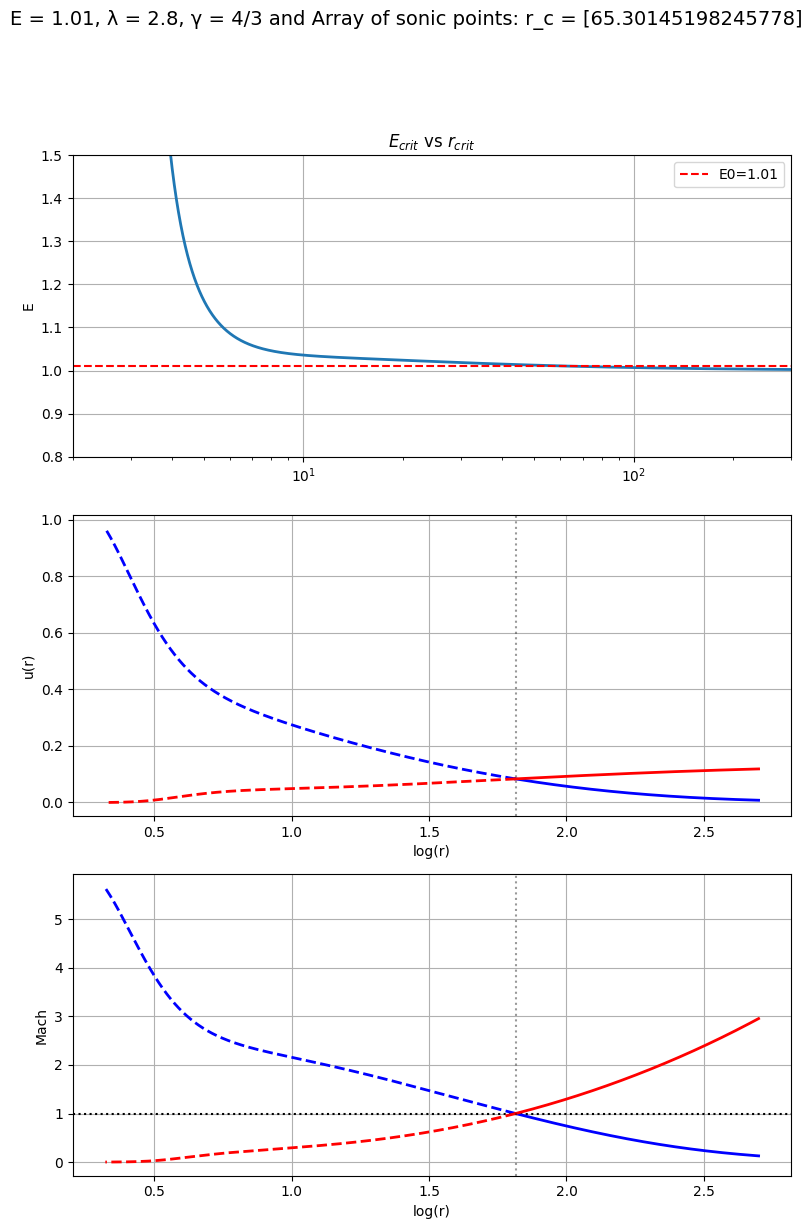

In [6]:
lam0 = 2.8
gamma0 = 4/3
E0 = 1.01

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# =====================  SCAN r_sonic  ===========================
# ================================================================
r_scan = np.linspace(2.4, 1500, 200000)

E_list = []
r_list = []

for R in r_scan:
    val = E_sonic_numeric(R, lam0, gamma0)
    if np.isfinite(val) and val > 0:
        r_list.append(R)
        E_list.append(val)

r_list = np.array(r_list)
E_list = np.array(E_list)

if len(r_list) == 0:
    raise RuntimeError("No valid sonic energy values found!")

F_list = E_list - E0

# ================================================================
# =====================  FIND SONIC RADII  =======================
# ================================================================
def F_num(R):
    return E_sonic_numeric(R, lam0, gamma0) - E0

root_guesses = []
for i in range(len(F_list) - 1):
    if np.isfinite(F_list[i]) and np.isfinite(F_list[i + 1]):
        if F_list[i] * F_list[i + 1] < 0:
            root_guesses.append(0.5 * (r_list[i] + r_list[i + 1]))

tol_near = 1e-3
for i, val in enumerate(F_list):
    if np.isfinite(val) and abs(val) < tol_near:
        root_guesses.append(r_list[i])

roots_raw = []
for g in root_guesses:
    r_root = newton_root(F_num, g)
    if np.isfinite(r_root) and 2.0 < r_root < 1200.0:
        roots_raw.append(r_root)

roots_raw = sorted(roots_raw)
unique_roots = []
for rr in roots_raw:
    if not unique_roots or abs(rr - unique_roots[-1]) > 1e-4:
        unique_roots.append(rr)

if not unique_roots:
    raise RuntimeError("No sonic radii found for this E0.")

print("\nSonic radii found:", unique_roots)

# ================================================================
# ======================  RK4 DEFINITIONS  =======================
# ================================================================
def du_dr_numeric(R, uval, csval):
    num = Num_func(R, uval, csval, gamma0, lam0)
    den = Denom_func(R, uval, csval, gamma0, lam0)
    if den == 0 or not np.isfinite(num / den):
        return np.nan
    return num / den

def dcs_dr_numeric(R, uval, csval):
    v_now = du_dr_numeric(R, uval, csval)
    if not np.isfinite(v_now):
        return np.nan
    return s_func(R, uval, csval, gamma0, lam0, v_now)

def rk4_step(R, uval, csval, h):
    k1u = h * du_dr_numeric(R, uval, csval)
    k1c = h * dcs_dr_numeric(R, uval, csval)

    k2u = h * du_dr_numeric(R + 0.5 * h, uval + 0.5 * k1u, csval + 0.5 * k1c)
    k2c = h * dcs_dr_numeric(R + 0.5 * h, uval + 0.5 * k1u, csval + 0.5 * k1c)

    k3u = h * du_dr_numeric(R + 0.5 * h, uval + 0.5 * k2u, csval + 0.5 * k2c)
    k3c = h * dcs_dr_numeric(R + 0.5 * h, uval + 0.5 * k2u, csval + 0.5 * k2c)

    k4u = h * du_dr_numeric(R + h, uval + k3u, csval + k3c)
    k4c = h * dcs_dr_numeric(R + h, uval + k3u, csval + k3c)

    u_new = uval + (k1u + 2 * k2u + 2 * k3u + k4u) / 6
    cs_new = csval + (k1c + 2 * k2c + 2 * k3c + k4c) / 6
    return u_new, cs_new

# ================================================================
# ======================  FIGURE SETUP  ==========================
# ================================================================
fig, (axE, axU, axM) = plt.subplots(3, 1, figsize=(8, 12))

# -------- E vs r_sonic --------
axE.plot(r_list, E_list, lw=2)
axE.axhline(E0, color='r', ls='--', label=f"E0={E0}")
axE.set_xscale('log')
axE.set_xlim(2, 300)
axE.set_ylim(0.8, 1.5)
axE.set_ylabel("E")
axE.set_title("$E_{crit}$ vs $r_{crit}$")
axE.grid()
axE.legend()

axU.set_ylabel("u(r)")
axU.set_xlabel("log(r)")
axU.grid()

axM.set_ylabel("Mach")
axM.set_xlabel("log(r)")
axM.axhline(1, color="k", ls=":")
axM.grid()

# ================================================================
# ===================  FLOW INTEGRATION  =========================
# ================================================================
for j, r0 in enumerate(unique_roots, start=1):

    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    crit = cs0

    subs = {r: r0, lam: lam0, gamma: gamma0, u: crit, cs: crit}
    a_num = float(a.subs(subs).evalf())
    b_num = float(b.subs(subs).evalf())
    c_num = float(c.subs(subs).evalf())

    vroots = np.roots([a_num, b_num, c_num])
    v_real = [float(vr.real) for vr in vroots if abs(vr.imag) < 1e-10]

    for v0 in v_real:

        s0 = float(s_func(r0, crit, crit, gamma0, lam0, v0))
        branch = "Wind" if v0 > 0 else "Accretion"
        color = "red" if branch == "Wind" else "blue"

        # ---------------- OUTWARD ----------------
        R = r0
        u_cur = crit
        cs_cur = crit
        h = 1e-2

        Rout, Uout, CSout = [], [], []

        R += h
        u_cur += h * v0
        cs_cur += h * s0

        while 2.1 < R < 500:
            Rout.append(R)
            Uout.append(u_cur)
            CSout.append(cs_cur)
            u_cur, cs_cur = rk4_step(R, u_cur, cs_cur, h)
            R += h

        # ---------------- INWARD ----------------
        R = r0
        u_cur = crit
        cs_cur = crit
        h = -1e-2

        Rin, Uin, CSin = [], [], []

        R += h
        u_cur += h * v0
        cs_cur += h * s0

        while 2.1 < R < 500:
            Rin.append(R)
            Uin.append(u_cur)
            CSin.append(cs_cur)
            u_cur, cs_cur = rk4_step(R, u_cur, cs_cur, h)
            R += h

        log_Rout = np.log10(Rout)
        log_Rin = np.log10(Rin)

        axU.plot(log_Rout, Uout, color=color, lw=2)
        axU.plot(log_Rin, Uin, color=color, lw=2, ls="--")

        axM.plot(log_Rout, np.array(Uout) / np.array(CSout), color=color, lw=2)
        axM.plot(log_Rin, np.array(Uin) / np.array(CSin), color=color, lw=2, ls="--")

    axU.axvline(np.log10(r0), color="k", ls=":", alpha=0.4)
    axM.axvline(np.log10(r0), color="k", ls=":", alpha=0.4)

global_title = f"E = {E0}, λ = {lam0}, γ = 4/3 and Array of sonic points: r_c = {unique_roots}"
plt.suptitle(global_title, fontsize=14, y=1.02)

# ================================================================
# ========================  SAVE FIGURE  =========================
# ================================================================
# Adjust layout after setting the title
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the title
plt.savefig("O-type_wedge_Schw.png")
plt.show()

# I-type solution(only inner sonic point exists)


Sonic radii found: [5.708985641450273]


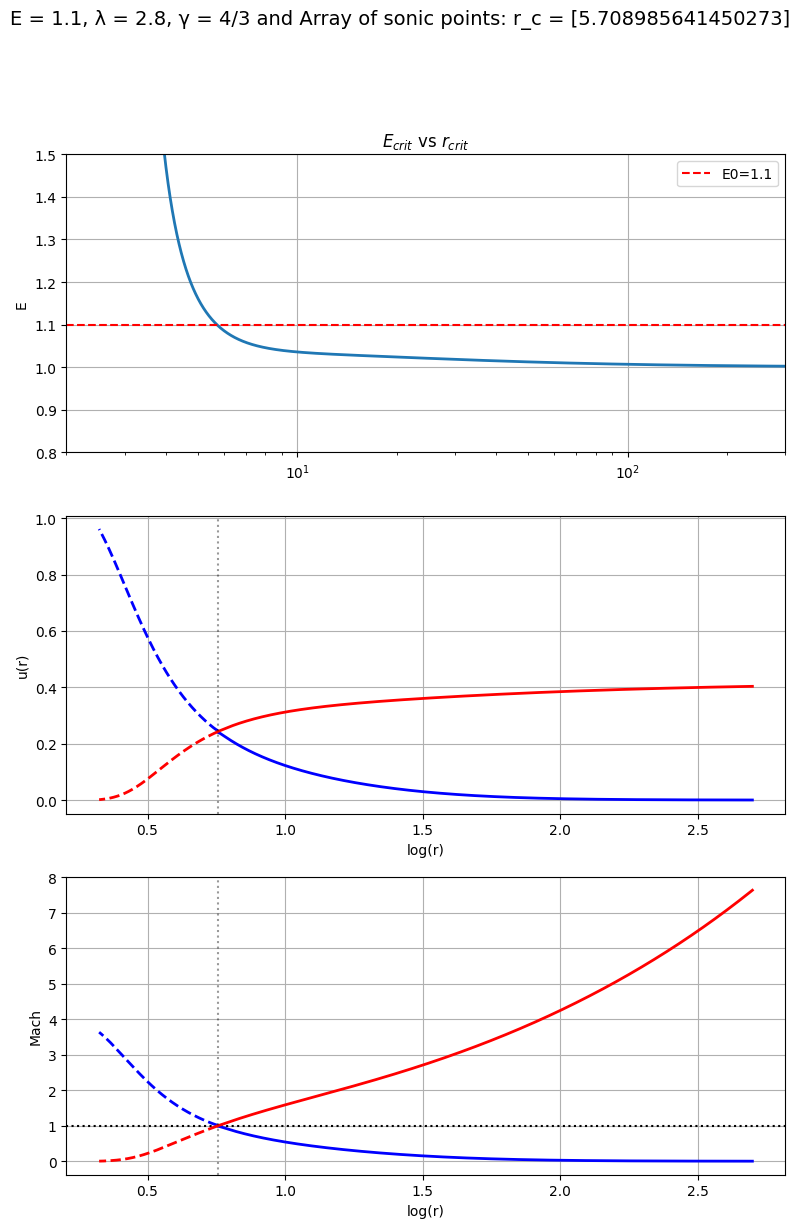

In [7]:
lam0 = 2.8
gamma0 = 4/3
E0 = 1.1

# ================================================================
# =====================  SCAN r_sonic  ===========================
# ================================================================
r_scan = np.linspace(2.4, 1500, 200000)

E_list = []
r_list = []

for R in r_scan:
    val = E_sonic_numeric(R, lam0, gamma0)
    if np.isfinite(val) and val > 0:
        r_list.append(R)
        E_list.append(val)

r_list = np.array(r_list)
E_list = np.array(E_list)

if len(r_list) == 0:
    raise RuntimeError("No valid sonic energy values found!")

F_list = E_list - E0

# ================================================================
# =====================  FIND SONIC RADII  =======================
# ================================================================
def F_num(R):
    return E_sonic_numeric(R, lam0, gamma0) - E0

root_guesses = []
for i in range(len(F_list) - 1):
    if np.isfinite(F_list[i]) and np.isfinite(F_list[i + 1]):
        if F_list[i] * F_list[i + 1] < 0:
            root_guesses.append(0.5 * (r_list[i] + r_list[i + 1]))

tol_near = 1e-3
for i, val in enumerate(F_list):
    if np.isfinite(val) and abs(val) < tol_near:
        root_guesses.append(r_list[i])

roots_raw = []
for g in root_guesses:
    r_root = newton_root(F_num, g)
    if np.isfinite(r_root) and 2.0 < r_root < 1200.0:
        roots_raw.append(r_root)

roots_raw = sorted(roots_raw)
unique_roots = []
for rr in roots_raw:
    if not unique_roots or abs(rr - unique_roots[-1]) > 1e-4:
        unique_roots.append(rr)

if not unique_roots:
    raise RuntimeError("No sonic radii found for this E0.")

print("\nSonic radii found:", unique_roots)

# ================================================================
# ======================  RK4 DEFINITIONS  =======================
# ================================================================
def du_dr_numeric(R, uval, csval):
    num = Num_func(R, uval, csval, gamma0, lam0)
    den = Denom_func(R, uval, csval, gamma0, lam0)
    if den == 0 or not np.isfinite(num / den):
        return np.nan
    return num / den

def dcs_dr_numeric(R, uval, csval):
    v_now = du_dr_numeric(R, uval, csval)
    if not np.isfinite(v_now):
        return np.nan
    return s_func(R, uval, csval, gamma0, lam0, v_now)

def rk4_step(R, uval, csval, h):
    k1u = h * du_dr_numeric(R, uval, csval)
    k1c = h * dcs_dr_numeric(R, uval, csval)

    k2u = h * du_dr_numeric(R + 0.5 * h, uval + 0.5 * k1u, csval + 0.5 * k1c)
    k2c = h * dcs_dr_numeric(R + 0.5 * h, uval + 0.5 * k1u, csval + 0.5 * k1c)

    k3u = h * du_dr_numeric(R + 0.5 * h, uval + 0.5 * k2u, csval + 0.5 * k2c)
    k3c = h * dcs_dr_numeric(R + 0.5 * h, uval + 0.5 * k2u, csval + 0.5 * k2c)

    k4u = h * du_dr_numeric(R + h, uval + k3u, csval + k3c)
    k4c = h * dcs_dr_numeric(R + h, uval + k3u, csval + k3c)

    u_new = uval + (k1u + 2 * k2u + 2 * k3u + k4u) / 6
    cs_new = csval + (k1c + 2 * k2c + 2 * k3c + k4c) / 6
    return u_new, cs_new

# ================================================================
# ======================  FIGURE SETUP  ==========================
# ================================================================
fig, (axE, axU, axM) = plt.subplots(3, 1, figsize=(8, 12))

# -------- E vs r_sonic --------
axE.plot(r_list, E_list, lw=2)
axE.axhline(E0, color='r', ls='--', label=f"E0={E0}")

axE.set_xscale('log')
axE.set_xlim(2, 300)
axE.set_ylim(0.8, 1.5)
axE.set_ylabel("E")
axE.set_title("$E_{crit}$ vs $r_{crit}$")
axE.grid()
axE.legend()

axU.set_ylabel("u(r)")
axU.set_xlabel("log(r)")
axU.grid()

axM.set_ylabel("Mach")
axM.set_xlabel("log(r)")
axM.axhline(1, color="k", ls=":")
axM.grid()

# ================================================================
# ===================  FLOW INTEGRATION  =========================
# ================================================================
for j, r0 in enumerate(unique_roots, start=1):

    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    crit = cs0

    subs = {r: r0, lam: lam0, gamma: gamma0, u: crit, cs: crit}
    a_num = float(a.subs(subs).evalf())
    b_num = float(b.subs(subs).evalf())
    c_num = float(c.subs(subs).evalf())

    vroots = np.roots([a_num, b_num, c_num])
    v_real = [float(vr.real) for vr in vroots if abs(vr.imag) < 1e-10]

    for v0 in v_real:

        s0 = float(s_func(r0, crit, crit, gamma0, lam0, v0))
        branch = "Wind" if v0 > 0 else "Accretion"
        color = "red" if branch == "Wind" else "blue"

        # ---------------- OUTWARD ----------------
        R = r0
        u_cur = crit
        cs_cur = crit
        h = 1e-2

        Rout, Uout, CSout = [], [], []

        R += h
        u_cur += h * v0
        cs_cur += h * s0

        while 2.1 < R < 500:
            Rout.append(R)
            Uout.append(u_cur)
            CSout.append(cs_cur)
            u_cur, cs_cur = rk4_step(R, u_cur, cs_cur, h)
            R += h

        # ---------------- INWARD ----------------
        R = r0
        u_cur = crit
        cs_cur = crit
        h = -1e-2

        Rin, Uin, CSin = [], [], []

        R += h
        u_cur += h * v0
        cs_cur += h * s0

        while 2.1 < R < 500:
            Rin.append(R)
            Uin.append(u_cur)
            CSin.append(cs_cur)
            u_cur, cs_cur = rk4_step(R, u_cur, cs_cur, h)
            R += h

        log_Rout = np.log10(Rout)
        log_Rin = np.log10(Rin)

        axU.plot(log_Rout, Uout, color=color, lw=2)
        axU.plot(log_Rin, Uin, color=color, lw=2, ls="--")

        axM.plot(log_Rout, np.array(Uout) / np.array(CSout), color=color, lw=2)
        axM.plot(log_Rin, np.array(Uin) / np.array(CSin), color=color, lw=2, ls="--")

    axU.axvline(np.log10(r0), color="k", ls=":", alpha=0.4)
    axM.axvline(np.log10(r0), color="k", ls=":", alpha=0.4)

global_title = f"E = {E0}, λ = {lam0}, γ = 4/3 and Array of sonic points: r_c = {unique_roots}"
plt.suptitle(global_title, fontsize=14, y=1.02)

# ================================================================
# ========================  SAVE FIGURE  =========================
# ================================================================
# Adjust layout after setting the title
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the title
plt.savefig("I-type_wedge_Schw.png")
plt.show()

# W-Type solution (both inner and outer sonic point are physical, global solution passes through inner and alpha-solution passes through outer)


================ ENERGY (NUMERIC ONLY) ================

Sonic radii found: [5.311279554936486, 15.22645793261125, 55.59846964188612]
-------------------------------------------------------------------------------------------------------------------------
Sonic point 1: r = 5.311279554936486 & u_crit: 0.16474868498403142

du/dr_critical 1: -0.3153710589331518

du/dr_critical 2: 0.10309457001057219

-------------------------------------------------------------------------------------------------------------------------
Sonic point 3: r = 55.59846964188612 & u_crit: 0.08650708874084319

du/dr_critical 1: -0.00986800466098036

du/dr_critical 2: 0.0004688671847829017



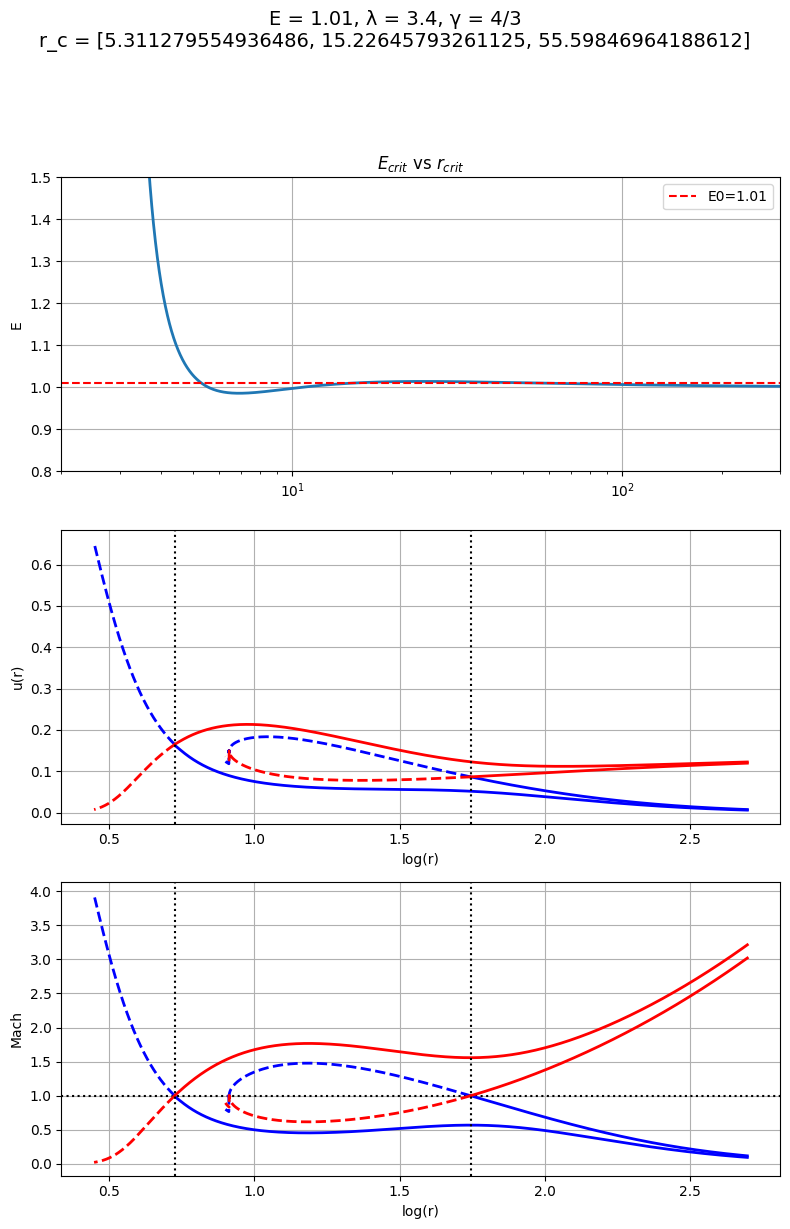

In [8]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


lam0 = 3.4
gamma0 = 4/3
E0 = 1.01


print("\n================ ENERGY (NUMERIC ONLY) ================")

# Scan r
r_scan = np.linspace(2.4, 1500, 200000)

E_list = []
r_list = []

for R in r_scan:
    val = E_sonic_numeric(R, lam0, gamma0)
    if np.isfinite(val) and val > 0:
        r_list.append(R)
        E_list.append(val)

r_list = np.array(r_list)
E_list = np.array(E_list)

if len(r_list)==0:
    raise RuntimeError("No valid sonic energy values found!")


fig, (axE, axU, axM) = plt.subplots(3, 1, figsize=(8, 12))

# -------- E vs r_sonic --------
axE.plot(r_list, E_list, lw=2)
axE.axhline(E0, color='r', ls='--', label=f"E0={E0}")
axE.set_xscale('log')
axE.set_xlim(2, 300)
axE.set_ylim(0.8, 1.5)
axE.set_ylabel("E")
axE.set_title("$E_{crit}$ vs $r_{crit}$")
axE.grid()
axE.legend()

axU.set_ylabel("u(r)")
axU.set_xlabel("log(r)")
axU.grid()

axM.set_ylabel("Mach")
axM.set_xlabel("log(r)")
axM.axhline(1, color="k", ls=":")
axM.grid()


# ---------------------------------------------------------------------
# Plot F(r) = E(r) - E0
# ---------------------------------------------------------------------
F_list = E_list - E0


# ---------------------------------------------------------------------
# Invert: find ALL r_sonic for desired E0 using F(r) and Newton-Raphson
# ---------------------------------------------------------------------
def F_num(R):
    return E_sonic_numeric(R, lam0, gamma0) - E0

# find zero-crossings of F_list to get initial guesses
root_guesses = []
for i in range(len(F_list)-1):
    if np.isfinite(F_list[i]) and np.isfinite(F_list[i+1]):
        if F_list[i] == 0.0:
            root_guesses.append(r_list[i])
        elif F_list[i]*F_list[i+1] < 0:
            root_guesses.append(0.5*(r_list[i] + r_list[i+1]))

# also include near-zero points as extra guesses (optional)
tol_near = 1e-3
for i, val in enumerate(F_list):
    if np.isfinite(val) and abs(val) < tol_near:
        root_guesses.append(r_list[i])

# refine each guess with Newton-Raphson
roots_raw = []
for g in root_guesses:
    r_root = newton_root(F_num, g)
    if np.isfinite(r_root) and 2.0 < r_root < 1200.0:
        roots_raw.append(r_root)

# de-duplicate roots
roots_raw = sorted(roots_raw)
unique_roots = []
tol_merge = 1e-4
for rr in roots_raw:
    if not unique_roots or abs(rr - unique_roots[-1]) > tol_merge:
        unique_roots.append(rr)

if not unique_roots:
    raise RuntimeError("No sonic radii found for this E0.")

print("\nSonic radii found:", unique_roots)

# ================================================================
# ======================   RK4 INTEGRATION   =====================
# ================================================================
def du_dr_numeric(R, uval, csval):
    num = Num_func(R, uval, csval, gamma0, lam0)
    den = Denom_func(R, uval, csval, gamma0, lam0)
    if den == 0 or not np.isfinite(num/den):
        return np.nan
    return num/den

def dcs_dr_numeric(R, uval, csval):
    v_now = du_dr_numeric(R, uval, csval)
    if not np.isfinite(v_now):
        return np.nan
    return s_func(R, uval, csval, gamma0, lam0, v_now)

def rk4_step(R, uval, csval, h):
    k1u = h * du_dr_numeric(R, uval, csval)
    k1c = h * dcs_dr_numeric(R, uval, csval)

    k2u = h * du_dr_numeric(R + 0.5*h, uval + 0.5*k1u, csval + 0.5*k1c)
    k2c = h * dcs_dr_numeric(R + 0.5*h, uval + 0.5*k1u, csval + 0.5*k1c)

    k3u = h * du_dr_numeric(R + 0.5*h, uval + 0.5*k2u, csval + 0.5*k2c)
    k3c = h * dcs_dr_numeric(R + 0.5*h, uval + 0.5*k2u, csval + 0.5*k2c)

    k4u = h * du_dr_numeric(R + h, uval + k3u, csval + k3c)
    k4c = h * dcs_dr_numeric(R + h, uval + k3u, csval + k3c)

    u_new  = uval  + (k1u + 2*k2u + 2*k3u + k4u)/6.0
    cs_new = csval + (k1c + 2*k2c + 2*k3c + k4c)/6.0
    return u_new, cs_new


# ================================================================
# ===================  PER-SONIC-POINT PLOTS  ====================
# ================================================================
for j, r0 in enumerate(unique_roots, start=1):

    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    crit = cs0   # u = cs at sonic

    # coefficients at sonic point
    a_num = float(a.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())
    b_num = float(b.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())
    c_num = float(c.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())

    vroots = np.roots([a_num,b_num,c_num])
    v_real = [float(vr.real) for vr in vroots if abs(vr.imag) < 1e-10]



for j, r0 in enumerate(unique_roots, start=1):

    # ---- skip the 2nd sonic point ----
    if j == 2:
        continue

    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    crit = cs0   # u = cs at sonic

    # coefficients at sonic point
    a_num = float(a.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())
    b_num = float(b.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())
    c_num = float(c.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())

    vroots = np.roots([a_num,b_num,c_num])
    v_real = [float(vr.real) for vr in vroots if abs(vr.imag) < 1e-10]

    print("-------------------------------------------------------------------------------------------------------------------------")
    print(f"Sonic point {j}: r = {r0} & u_crit: {cs0}\n")

    f = -(lam0**2/r0**3)*((1-3/r0)/(1 - lam0**2*(1-2/r0)/r0**2))  + 1/(r0**2 - 2*r0)
    A  = (2/r0) + 1/(r0**2 - 2*r0)
    cs_loop = np.sqrt(f/A)

    cnt = 1
    for v0 in v_real:

        print(f"du/dr_critical {cnt}: {v0}\n")
        cnt += 1

        s0 = float(s_func(r0, crit, crit, gamma0, lam0, v0))
        branch = "Wind" if v0 > 0 else "Accretion"
        color  = "red" if branch=="Wind" else "blue"

        # ---------------- OUTWARD ----------------
        R = r0
        u_cur = crit
        cs_cur = crit

        h = 1e-2
        Rout, Uout, CSout = [R], [u_cur], [cs_cur]

        R += h
        u_cur += h*v0
        cs_cur += h*s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rout.append(R); Uout.append(u_cur); CSout.append(cs_cur)

            while(R< 1000 and R>2.8):
                if R >= 500.0:
                    break
                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h
                if not np.isfinite(u_next) or not np.isfinite(cs_next):
                    break
                if cs_next <= 0 or cs_next >= 1:
                    break
                if u_next <= 0 or u_next >= 1:
                    break
                Rout.append(R); Uout.append(u_next); CSout.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        # ---------------- INWARD ----------------
        R = r0
        u_cur = crit
        cs_cur = crit
        h = -1e-4
        Rin, Uin, CSin = [R], [u_cur], [cs_cur]

        R += h
        u_cur += h*v0
        cs_cur += h*s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rin.append(R); Uin.append(u_cur); CSin.append(cs_cur)

            while(R< 1000 and R>2.8):
                if R <= 2.1:
                    break
                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h
                if not np.isfinite(u_next) or not np.isfinite(cs_next):
                    break
                if cs_next <= 0 or cs_next >= 1:
                    break
                if u_next <= 0 or u_next >= 1:
                    break
                Rin.append(R); Uin.append(u_next); CSin.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        # ---- keep your EXACT clipping rule for sonic 3 ----
        if j == 3:
            clip_index = np.where(np.array(Rin) >= 10**0.9)[0]
            Rin = np.array(Rin)[clip_index].tolist()
            Uin = np.array(Uin)[clip_index].tolist()
            CSin = np.array(CSin)[clip_index].tolist()

        # ================== PLOT ==================
        log_Rout = np.log10(Rout)
        log_Rin  = np.log10(Rin)

        axU.plot(log_Rout, Uout, color=color, lw=2, label=f"SP{j} {branch} (out)")
        axU.plot(log_Rin,  Uin,  color=color, lw=2, ls="--", label=f"SP{j} {branch} (in)")

        axM.plot(log_Rout, np.array(Uout)/np.array(CSout), color=color, lw=2)
        axM.plot(log_Rin,  np.array(Uin)/np.array(CSin),  color=color, lw=2, ls="--")

    axU.axvline(np.log10(r0), color="k", ls=":")
    axM.axvline(np.log10(r0), color="k", ls=":")

global_title = f"E = {E0}, λ = {lam0}, γ = 4/3\nr_c = {unique_roots}"
plt.suptitle(global_title, fontsize=14, y=1.02)

# ================================================================
# ========================  SAVE FIGURE  =========================
# ================================================================
# Adjust layout after setting the title
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the title
plt.savefig("W-type_wedge_Schw.png")
plt.show()


# Type A (Both inner and outer sonic point exist and transonic solution passes though outer while alpha-solution passes though inner)


================ ENERGY (NUMERIC ONLY) ================

Sonic radii found: [6.526120825225706, 8.86736492403572, 735.7576707459898]
-------------------------------------------------------------------------------------------------------------------------
Sonic point 1: r = 6.526120825225706 & u_crit: 0.15448919191406701

du/dr_critical 1: -0.1774552963777417

du/dr_critical 2: 0.020984923730074642

-------------------------------------------------------------------------------------------------------------------------
Sonic point 3: r = 735.7576707459898 & u_crit: 0.025902685310404978

du/dr_critical 1: -0.00023198022261779097

du/dr_critical 2: 2.0650813707404493e-05



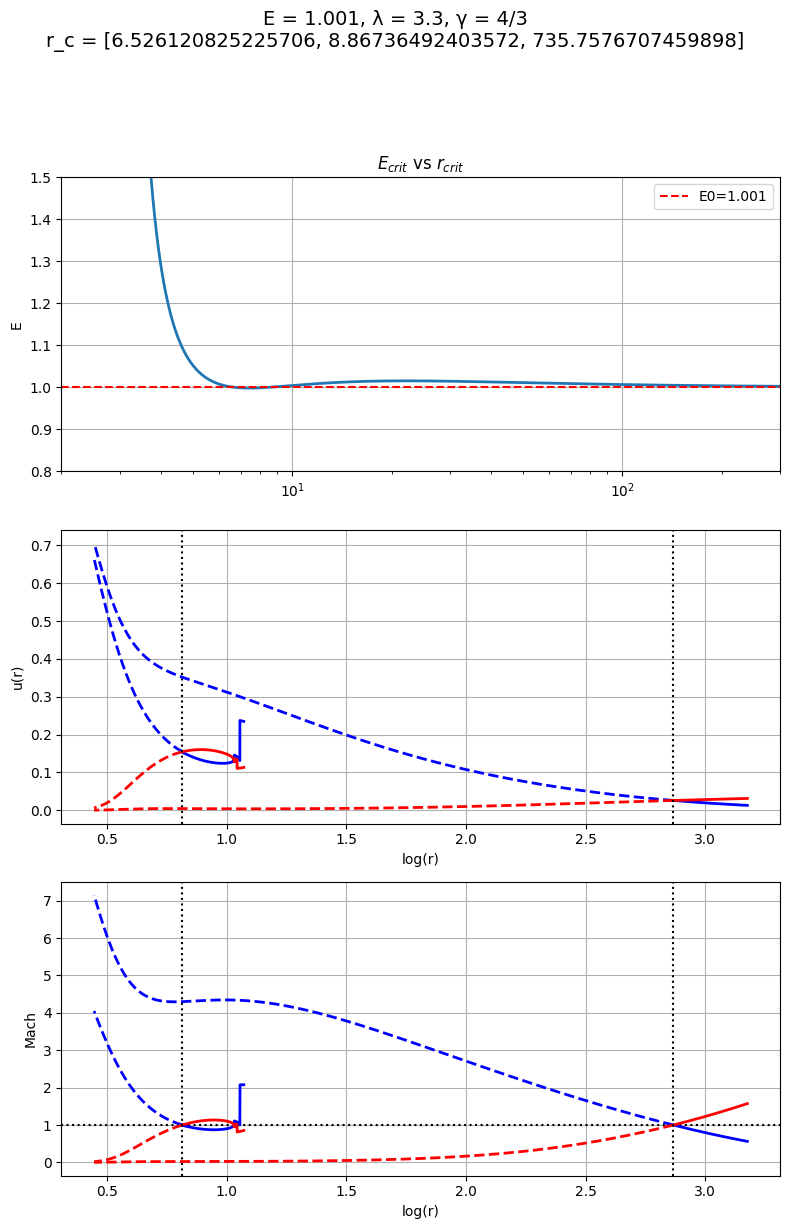

In [9]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


lam0 = 3.3
gamma0 = 4/3
E0 = 1.001


print("\n================ ENERGY (NUMERIC ONLY) ================")

# Scan r
r_scan = np.linspace(2.4, 1500, 200000)

E_list = []
r_list = []

for R in r_scan:
    val = E_sonic_numeric(R, lam0, gamma0)
    if np.isfinite(val) and val > 0:
        r_list.append(R)
        E_list.append(val)

r_list = np.array(r_list)
E_list = np.array(E_list)

if len(r_list)==0:
    raise RuntimeError("No valid sonic energy values found!")


fig, (axE, axU, axM) = plt.subplots(3, 1, figsize=(8, 12))

# -------- E vs r_sonic --------
axE.plot(r_list, E_list, lw=2)
axE.axhline(E0, color='r', ls='--', label=f"E0={E0}")
axE.set_xscale('log')
axE.set_xlim(2, 300)
axE.set_ylim(0.8, 1.5)
axE.set_ylabel("E")
axE.set_title("$E_{crit}$ vs $r_{crit}$")
axE.grid()
axE.legend()

axU.set_ylabel("u(r)")
axU.set_xlabel("log(r)")
axU.grid()

axM.set_ylabel("Mach")
axM.set_xlabel("log(r)")
axM.axhline(1, color="k", ls=":")
axM.grid()


# ---------------------------------------------------------------------
# Plot F(r) = E(r) - E0
# ---------------------------------------------------------------------
F_list = E_list - E0


# ---------------------------------------------------------------------
# Invert: find ALL r_sonic for desired E0 using F(r) and Newton-Raphson
# ---------------------------------------------------------------------
def F_num(R):
    return E_sonic_numeric(R, lam0, gamma0) - E0

# find zero-crossings of F_list to get initial guesses
root_guesses = []
for i in range(len(F_list)-1):
    if np.isfinite(F_list[i]) and np.isfinite(F_list[i+1]):
        if F_list[i] == 0.0:
            root_guesses.append(r_list[i])
        elif F_list[i]*F_list[i+1] < 0:
            root_guesses.append(0.5*(r_list[i] + r_list[i+1]))

# also include near-zero points as extra guesses (optional)
tol_near = 1e-3
for i, val in enumerate(F_list):
    if np.isfinite(val) and abs(val) < tol_near:
        root_guesses.append(r_list[i])

# refine each guess with Newton-Raphson
roots_raw = []
for g in root_guesses:
    r_root = newton_root(F_num, g)
    if np.isfinite(r_root) and 2.0 < r_root < 1200.0:
        roots_raw.append(r_root)

# de-duplicate roots
roots_raw = sorted(roots_raw)
unique_roots = []
tol_merge = 1e-4
for rr in roots_raw:
    if not unique_roots or abs(rr - unique_roots[-1]) > tol_merge:
        unique_roots.append(rr)

if not unique_roots:
    raise RuntimeError("No sonic radii found for this E0.")

print("\nSonic radii found:", unique_roots)

# ================================================================
# ======================   RK4 INTEGRATION   =====================
# ================================================================
def du_dr_numeric(R, uval, csval):
    num = Num_func(R, uval, csval, gamma0, lam0)
    den = Denom_func(R, uval, csval, gamma0, lam0)
    if den == 0 or not np.isfinite(num/den):
        return np.nan
    return num/den

def dcs_dr_numeric(R, uval, csval):
    v_now = du_dr_numeric(R, uval, csval)
    if not np.isfinite(v_now):
        return np.nan
    return s_func(R, uval, csval, gamma0, lam0, v_now)

def rk4_step(R, uval, csval, h):
    k1u = h * du_dr_numeric(R, uval, csval)
    k1c = h * dcs_dr_numeric(R, uval, csval)

    k2u = h * du_dr_numeric(R + 0.5*h, uval + 0.5*k1u, csval + 0.5*k1c)
    k2c = h * dcs_dr_numeric(R + 0.5*h, uval + 0.5*k1u, csval + 0.5*k1c)

    k3u = h * du_dr_numeric(R + 0.5*h, uval + 0.5*k2u, csval + 0.5*k2c)
    k3c = h * dcs_dr_numeric(R + 0.5*h, uval + 0.5*k2u, csval + 0.5*k2c)

    k4u = h * du_dr_numeric(R + h, uval + k3u, csval + k3c)
    k4c = h * dcs_dr_numeric(R + h, uval + k3u, csval + k3c)

    u_new  = uval  + (k1u + 2*k2u + 2*k3u + k4u)/6.0
    cs_new = csval + (k1c + 2*k2c + 2*k3c + k4c)/6.0
    return u_new, cs_new


# ================================================================
# ===================  PER-SONIC-POINT PLOTS  ====================
# ================================================================
for j, r0 in enumerate(unique_roots, start=1):

    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    crit = cs0   # u = cs at sonic

    # coefficients at sonic point
    a_num = float(a.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())
    b_num = float(b.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())
    c_num = float(c.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())

    vroots = np.roots([a_num,b_num,c_num])
    v_real = [float(vr.real) for vr in vroots if abs(vr.imag) < 1e-10]



for j, r0 in enumerate(unique_roots, start=1):

    # ---- skip the 2nd sonic point ----
    if j == 2:
        continue

    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    crit = cs0   # u = cs at sonic

    # coefficients at sonic point
    a_num = float(a.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())
    b_num = float(b.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())
    c_num = float(c.subs({r:r0, lam:lam0, gamma:gamma0, u:crit, cs:crit}).evalf())

    vroots = np.roots([a_num,b_num,c_num])
    v_real = [float(vr.real) for vr in vroots if abs(vr.imag) < 1e-10]

    print("-------------------------------------------------------------------------------------------------------------------------")
    print(f"Sonic point {j}: r = {r0} & u_crit: {cs0}\n")

    f = -(lam0**2/r0**3)*((1-3/r0)/(1 - lam0**2*(1-2/r0)/r0**2))  + 1/(r0**2 - 2*r0)
    A  = (2/r0) + 1/(r0**2 - 2*r0)
    cs_loop = np.sqrt(f/A)

    cnt = 1
    for v0 in v_real:

        print(f"du/dr_critical {cnt}: {v0}\n")
        cnt += 1

        s0 = float(s_func(r0, crit, crit, gamma0, lam0, v0))
        branch = "Wind" if v0 > 0 else "Accretion"
        color  = "red" if branch=="Wind" else "blue"

        # ---------------- OUTWARD ----------------
        R = r0
        u_cur = crit
        cs_cur = crit

        h = 1e-2
        Rout, Uout, CSout = [R], [u_cur], [cs_cur]

        R += h
        u_cur += h*v0
        cs_cur += h*s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rout.append(R); Uout.append(u_cur); CSout.append(cs_cur)

            while(R< 1500 and R>2.8):
                if(j == 1 and R>11.8):
                    break
                
                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h
                if not np.isfinite(u_next) or not np.isfinite(cs_next):
                    break
                if cs_next <= 0 or cs_next >= 1:
                    break
                if u_next <= 0 or u_next >= 1:
                    break
                Rout.append(R); Uout.append(u_next); CSout.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        # ---------------- INWARD ----------------
        R = r0
        u_cur = crit
        cs_cur = crit
        h = -1e-2
        Rin, Uin, CSin = [R], [u_cur], [cs_cur]

        R += h
        u_cur += h*v0
        cs_cur += h*s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rin.append(R); Uin.append(u_cur); CSin.append(cs_cur)

            while(R< 1000 and R>2.8):
                if R <= 2.1:
                    break
                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h
                if not np.isfinite(u_next) or not np.isfinite(cs_next):
                    break
                if cs_next <= 0 or cs_next >= 1:
                    break
                if u_next <= 0 or u_next >= 1:
                    break
                Rin.append(R); Uin.append(u_next); CSin.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        # ---- keep your EXACT clipping rule for sonic 3 ----
        if j == 3:
            clip_index = np.where(np.array(Rin) >= 2.5)[0]
            Rin = np.array(Rin)[clip_index].tolist()
            Uin = np.array(Uin)[clip_index].tolist()
            CSin = np.array(CSin)[clip_index].tolist()

        # ================== PLOT ==================
        log_Rout = np.log10(Rout)
        log_Rin  = np.log10(Rin)

        axU.plot(log_Rout, Uout, color=color, lw=2, label=f"SP{j} {branch} (out)")
        axU.plot(log_Rin,  Uin,  color=color, lw=2, ls="--", label=f"SP{j} {branch} (in)")

        axM.plot(log_Rout, np.array(Uout)/np.array(CSout), color=color, lw=2)
        axM.plot(log_Rin,  np.array(Uin)/np.array(CSin),  color=color, lw=2, ls="--")

    axU.axvline(np.log10(r0), color="k", ls=":")
    axM.axvline(np.log10(r0), color="k", ls=":")

global_title = f"E = {E0}, λ = {lam0}, γ = 4/3\nr_c = {unique_roots}"
plt.suptitle(global_title, fontsize=14, y=1.02)

# ================================================================
# ========================  SAVE FIGURE  =========================
# ================================================================
# Adjust layout after setting the title
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the title
plt.savefig("A-type_wedge_Schw.png")
plt.show()


# E_c vs r_c plot for varying $\lambda$

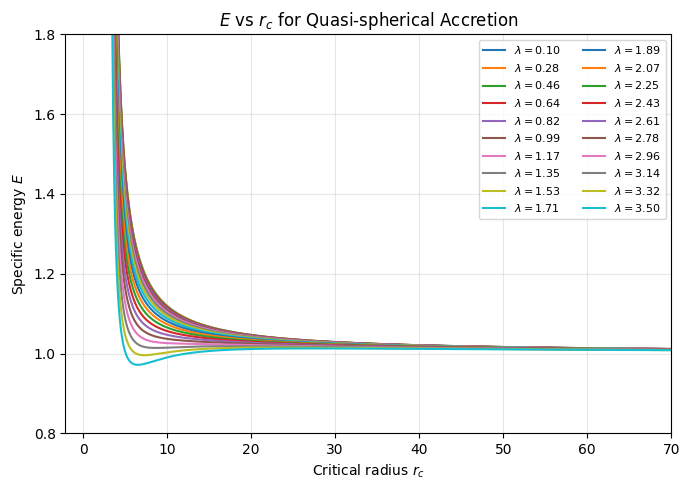

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def Ec_computed_given_rc(r, lam, gamma):
    f1 = -(lam**2/r**3)*(1-(3/r))/(1 - (1-(2/r))*(lam/r)**2)  + 1/((1-(2/r))*r**2)
    f2 = (2/r + 1/((1-2/r)*r**2))
    if(f1 < 0):
        print("Error : f1 < 0 for r = ",r,"lam = ",lam)
    if(f2 < 0):
        print("Error : f1 < 0 for r = ",r,"lam = ",lam)
    cs = np.sqrt(f1/f2)
    factor = (gamma - 1)/(gamma - 1 - cs**2)
    return factor * np.sqrt((1-2/r)/((1-cs**2)*(1-(1-2/r)*lam**2/r**2)))
    
def plot_Ec_vs_rc():
    gamma = 4.0 / 3.0

    plt.figure(figsize=(7,5))

    rc_vals = np.linspace(2.1, 1000.0, 50000)
    lam_vals = np.linspace(0.1, 3.5, 20)

    
    for lam in lam_vals:

        r_list = []
        E_list = []

        for r in rc_vals:
            E = Ec_computed_given_rc(r, lam, gamma)

            # keep only physical values
            if np.isfinite(E) and E > 0.0:
                r_list.append(r)
                E_list.append(E)

        if len(r_list) > 0:
            plt.plot(
                r_list,
                E_list,
                lw=1.5,
                label=rf"$\lambda={lam:.2f}$"
            )

    plt.xlabel(r"Critical radius $r_c$")
    plt.ylabel(r"Specific energy $E$")
    plt.ylim(0.8,1.8)
    plt.xlim(-2.1,70.0)
    plt.title(r"$E$ vs $r_c$ for Quasi-spherical Accretion")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


plot_Ec_vs_rc()


/tmp/ipykernel_85763/2425173380.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")
/tmp/ipykernel_85763/2425173380.py:54: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(-2.1,120.0)


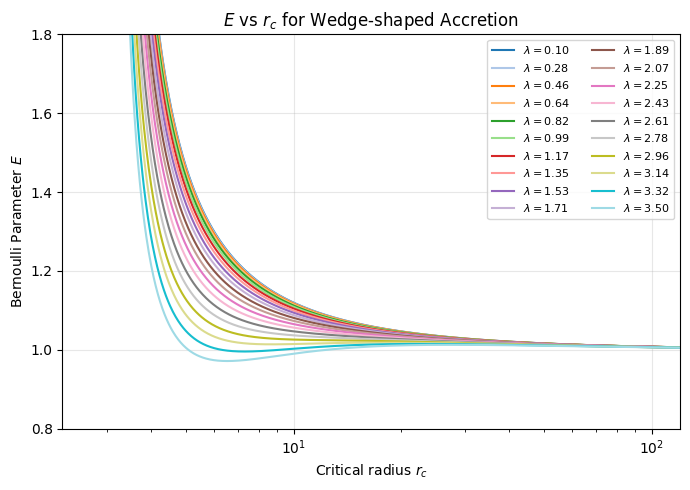

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

def Ec_computed_given_rc(r, lam, gamma):
    f1 = -(lam**2/r**3)*(1-(3/r))/(1 - (1-(2/r))*(lam/r)**2)  + 1/((1-(2/r))*r**2)
    f2 = (2/r + 1/((1-2/r)*r**2))
    if(f1 < 0):
        print("Error : f1 < 0 for r = ",r,"lam = ",lam)
    if(f2 < 0):
        print("Error : f1 < 0 for r = ",r,"lam = ",lam)
    cs = np.sqrt(f1/f2)
    factor = (gamma - 1)/(gamma - 1 - cs**2)
    return factor * np.sqrt((1-2/r)/((1-cs**2)*(1-(1-2/r)*lam**2/r**2)))
    
def plot_Ec_vs_rc():
    gamma = 4.0 / 3.0

    plt.figure(figsize=(7,5))

    rc_vals = np.linspace(2.1, 1000.0, 50000)
    lam_vals = np.linspace(0.1, 3.5, 20)

    # Use the tab20 colormap for more distinct colors
    cmap = get_cmap("tab20")
    colors = cmap(np.linspace(0, 1, len(lam_vals)))
    
    for lam, color in zip(lam_vals, colors):

        r_list = []
        E_list = []

        for r in rc_vals:
            E = Ec_computed_given_rc(r, lam, gamma)

            # keep only physical values
            if np.isfinite(E) and E > 0.0:
                r_list.append(r)
                E_list.append(E)

        if len(r_list) > 0:
            plt.plot(
                r_list,
                E_list,
                lw=1.5,
                label=rf"$\lambda={lam:.2f}$",
                color=color
            )

    plt.xlabel(r"Critical radius $r_c$")
    plt.ylabel(r"Bernoulli Parameter $E$")
    plt.xscale('log')
    plt.ylim(0.8,1.8)
    plt.xlim(-2.1,120.0)
    plt.title(r"$E$ vs $r_c$ for Wedge-shaped Accretion")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig("Wedge-EvsRc.png")
    plt.show()


plot_Ec_vs_rc()